In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/ML/3preprocessing/dropped_corr.csv")

In [ ]:
df=df.drop(columns='Volume_Dollar')

In [ ]:
df.columns

Index(['Date', 'Price_Gold', 'Volume_Gold', 'Change%_Gold', 'Price_Oil',
       'Price_Dollar', 'Price_Stocks', 'Volume_Stocks'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)
df.head()

,Price_Gold,Volume_Gold,Change%_Gold,Price_Oil,Price_Dollar,Price_Stocks,Volume_Stocks
Date,,,,,,,
1992-12-30,333.3,1760.0,0.15,19.63,92.169998,438.820007,183930000
1992-12-31,333.1,20180.0,-0.06,19.49,92.360001,435.709991,165910000
1993-01-04,328.4,14850.0,-1.41,19.03,93.459999,435.380005,201210000
1993-01-05,329.0,20380.0,0.18,19.13,92.629997,434.339996,240350000
1993-01-06,330.1,18110.0,0.33,19.03,93.070000,434.519989,295240000


In [ ]:

features = ['Price_Gold', 'Volume_Gold', 'Change%_Gold', 'Price_Oil',
            'Price_Dollar', 'Price_Stocks', 'Volume_Stocks']

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

scaled_data = pd.DataFrame(scaled_data, columns=features, index=df.index)


In [ ]:

n_days = 30  # use past 30 days

X = []
y = []

for i in range(n_days, len(scaled_data)):
    X.append(scaled_data.iloc[i-n_days:i].values)  # past 30 days
    y.append(scaled_data.iloc[i]['Price_Gold'])    # target

X, y = np.array(X), np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (8125, 30, 7)
y shape: (8125,)


In [ ]:

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [ ]:

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(1))  # predict Price_Gold

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        11,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,851 (124.42 KB)

 Trainable params: 31,851 (124.42 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)


Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.0041 - val_loss: 0.0010
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 4.4081e-04 - val_loss: 5.0450e-04
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 3.0946e-04 - val_loss: 2.8330e-04
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 2.6555e-04 - val_loss: 4.7304e-04
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 2.4171e-04 - val_loss: 2.8771e-04
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 1.9587e-04 - val_loss: 2.6074e-04
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 1.9716e-04 - val_loss: 1.4525e-04
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 1.9120e-04 - val_loss: 3.8831e-04
Epoch 9/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 1.7417e-04 - val_loss: 4.8953e-04
Epoch 10/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 1.7800e-04 - val_loss: 3.0851e-04
Epoch 11/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - 

In [ ]:
predicted = model.predict(X_test)

# If you want to convert back to original scale:
y_test_scaled = y_test.reshape(-1, 1)
predicted_scaled = predicted

# Since only Price_Gold is scaled, we can invert scaling
gold_scaler = MinMaxScaler()
gold_scaler.min_, gold_scaler.scale_ = scaler.min_[0], scaler.scale_[0]  # Price_Gold index=0
predicted_original = gold_scaler.inverse_transform(predicted_scaled)
y_test_original = gold_scaler.inverse_transform(y_test_scaled)


51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [28]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have:
# y_test_original -> actual gold prices
# predicted_original -> predicted gold prices by LSTM

# 1️⃣ Compute performance metrics
mse = mean_squared_error(y_test_original, predicted_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, predicted_original)
r2 = r2_score(y_test_original, predicted_original)

print("Performance Metrics for Gold Price Prediction:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.4f}")



Performance Metrics for Gold Price Prediction:
Mean Squared Error (MSE): 33935.74
Root Mean Squared Error (RMSE): 184.22
Mean Absolute Error (MAE): 117.77
R² Score: 0.8922


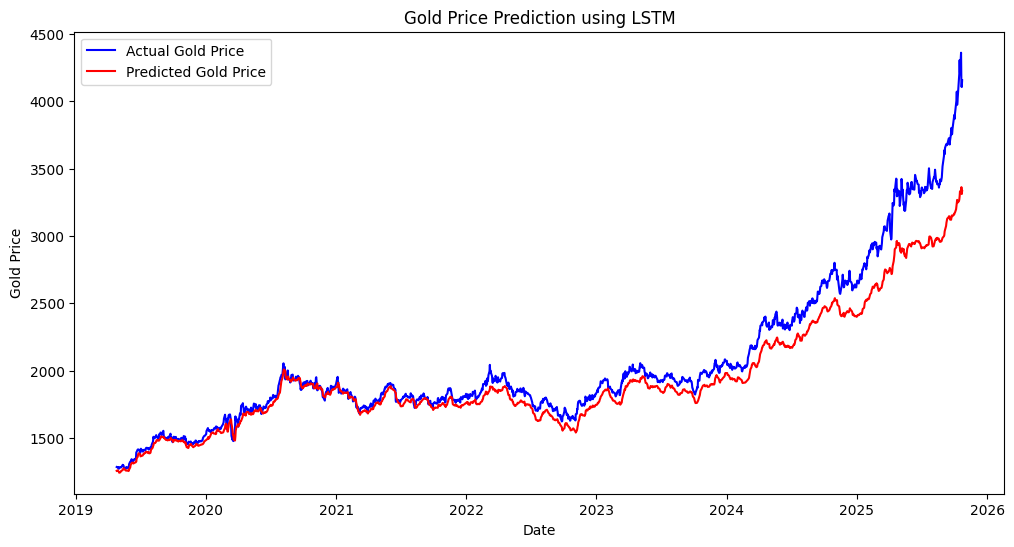

In [29]:
plt.figure(figsize=(12,6))
plt.plot(df.index[-len(y_test):], y_test_original, color='blue', label='Actual Gold Price')
plt.plot(df.index[-len(y_test):], predicted_original, color='red', label='Predicted Gold Price')
plt.title('Gold Price Prediction using LSTM')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.show()
